In [1]:
import numpy as np
import matplotlib.pyplot as plt   
from PostprocessingFunctions import write_vtk  

In [2]:
%%bash
cd ..
g++ -std=c++17 -Wall Airfoil.cpp SRC/Mesh.cpp SRC/Flux.cpp SRC/Simulation.cpp SRC/Solver.cpp SRC/Cell.cpp -o myprogram

        

SRC/Flux.cpp: In member function ‘std::pair<std::array<double, 4>, std::array<double, 4> > Flux::MusclExtrapolation(Cell*, char)’:
SRC/Flux.cpp:505:26: warning: unused variable ‘tol’ [-Wunused-variable]
  505 |             const double tol = 1e-14;
      |                          ^~~
SRC/Simulation.cpp: In member function ‘void Simulation::write_Cd(const string&)’:
SRC/Simulation.cpp:68:12: warning: unused variable ‘Cd’ [-Wunused-variable]
   68 |     double Cd = 0.0;
      |            ^~
SRC/Solver.cpp: In member function ‘void Solver::set_mms_bcs(Cell*)’:
SRC/Solver.cpp:220:12: warning: unused variable ‘gamma’ [-Wunused-variable]
  220 |     double gamma = 1.4;
      |            ^~~~~
SRC/Solver.cpp: At global scope:
SRC/Solver.cpp:179:15: warning: ‘double total_velocity(double, double, double, double)’ defined but not used [-Wunused-function]
  179 | static double total_velocity(double gamma, double M, double R, double T) {
      |               ^~~~~~~~~~~~~~
SRC/Solver.cpp:168:

In [3]:
%%bash
cd ..
./myprogram

Shape = (9984, 4)
setting pointersSetting boundary types
Setting ambient Conditions...Setting inflow Conditions...Freestream Pressure: 65855.8   Freestream Density: 0.764876 Freestream vel291.639Iteration: 0
  Density   : 320.803  U-velocity: 93558.6  V-velocity: 1.85272e-10  Pressure  : 1.10317e+08
Iteration: 1
  Density   : 306.331  U-velocity: 76853.2  V-velocity: 14965.8  Pressure  : 1.03892e+08
Iteration: 2
  Density   : 288.801  U-velocity: 61015.7  V-velocity: 26978.2  Pressure  : 9.67534e+07
Iteration: 3
  Density   : 269.397  U-velocity: 46494  V-velocity: 36326.8  Pressure  : 8.91922e+07
Iteration: 4
  Density   : 248.945  U-velocity: 33880.7  V-velocity: 43194.4  Pressure  : 8.14193e+07
Iteration: 5
  Density   : 228.104  U-velocity: 24196.5  V-velocity: 47805.5  Pressure  : 7.36255e+07
Iteration: 6
  Density   : 207.425  U-velocity: 19195.5  V-velocity: 50421.4  Pressure  : 6.59907e+07
Iteration: 7
  Density   : 187.384  U-velocity: 19813.2  V-velocity: 51330.5  Pressure  :

In [5]:
import matplotlib.pyplot as plt

data = np.loadtxt("../airfoil_primitives.csv", delimiter=",")
NI = 52
NJ = 192
print(data.shape)   # (4, Ncells)
rho = data[0, :].reshape((NI,NJ))
u   = data[1, :].reshape((NI,NJ))
v   = data[2, :].reshape((NI,NJ))
p   = data[3, :].reshape((NI,NJ))


(5, 9984)


In [6]:
rho.shape

(52, 192)

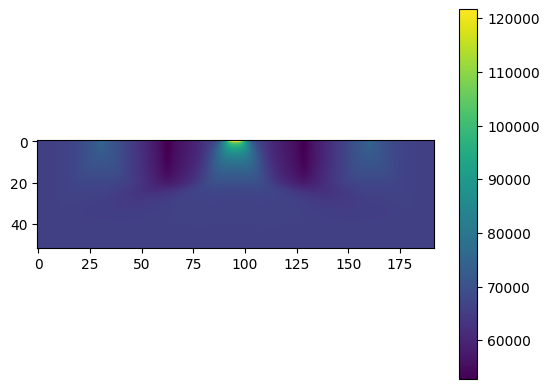

In [7]:

plt.imshow(p)
plt.colorbar()

In [8]:
from PostprocessingFunctions import load_grid
#x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.coarse.53x27.grd")
x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.medium.193x53.grd")
#x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.extra-coarse.27x14.grd")


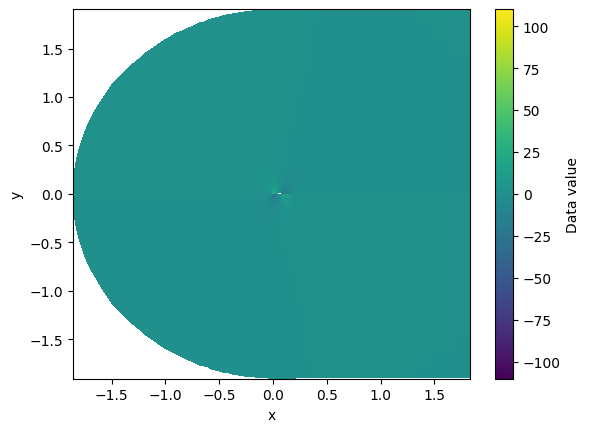

In [9]:
 

plt.pcolormesh(x[:,:], y[:,:], v[:,:], shading='auto', cmap='viridis')
plt.colorbar(label="Data value")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [10]:

nxi_top = -(y[:,1:]-y[:,0:-1])
nyi_top = x[:,1:]-x[:,0:-1]


nxi_top = -(y[:,1:]-y[:,0:-1])
nx = (-(nxi_top)[0:-1,:])[0,:]
ny = (-(nyi_top)[0:-1,:])[0,:]


In [11]:
p_inf = 65855.8
rho_inf = 0.764876
V_inf = 291.639
chord = .1524
q_inf = .5*rho_inf*V_inf**2
q_inf

p0 = 104532

74.38835699296479

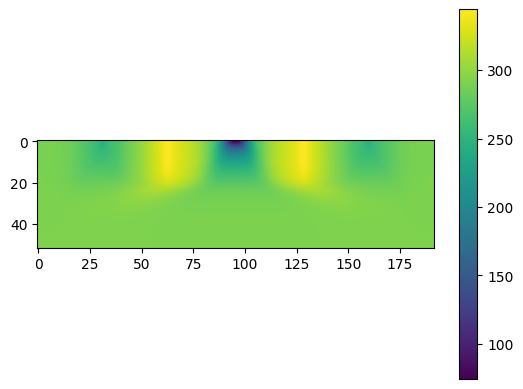

In [12]:
plt.imshow(u)

plt.colorbar()
np.min(u)

In [13]:
nx

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.82103158e-05, -2.49264140e-05, -3.36216035e-05, -4.42275705e-05,
       -5.03697520e-05, -5.18391898e-05, -7.09362357e-05, -1.32023735e-04,
       -1.84448552e-04, -2.03666219e-04, -2.07177538e-04, -2.03800621e-04,
       -2.04602256e-04, -2.07796576e-04, -2.10564234e-04, -2.12445389e-04,
       -2.13168561e-04, -2.12355517e-04, -2.10596481e-04, -2.06760364e-04,
       -2.01561488e-04, -

In [14]:
p_at_face = p[0,:]+.5*(p[1,:]-p[0,:])
(p_at_face-p_inf)/q_inf

array([ 2.48542595e-04,  2.48604061e-04,  2.87966307e-04,  3.63448594e-04,
        4.87634215e-04,  6.85450860e-04,  9.98069193e-04,  1.48877646e-03,
        2.24911268e-03,  3.40341613e-03,  5.10866687e-03,  7.54463711e-03,
        1.08858040e-02,  1.53098821e-02,  2.09656569e-02,  2.79414774e-02,
        3.62432859e-02,  4.57884385e-02,  5.64238485e-02,  6.79644477e-02,
        8.02344349e-02,  9.30946849e-02,  1.06454230e-01,  1.20276054e-01,
        1.34588474e-01,  1.49508552e-01,  1.65286342e-01,  1.82397136e-01,
        2.01756086e-01,  2.25235403e-01,  2.56508795e-01,  2.95537764e-01,
        2.28722813e-01,  2.03564865e-01,  1.81549150e-01,  1.63140674e-01,
        1.48149897e-01,  1.35077965e-01,  1.26074868e-01,  1.18909860e-01,
        8.93895388e-02,  5.62187734e-02,  3.15240203e-02,  1.62881962e-02,
        9.75823091e-04, -1.62655696e-02, -3.44104043e-02, -5.34197748e-02,
       -7.32775576e-02, -9.35494256e-02, -1.15209911e-01, -1.37118768e-01,
       -1.60116691e-01, -

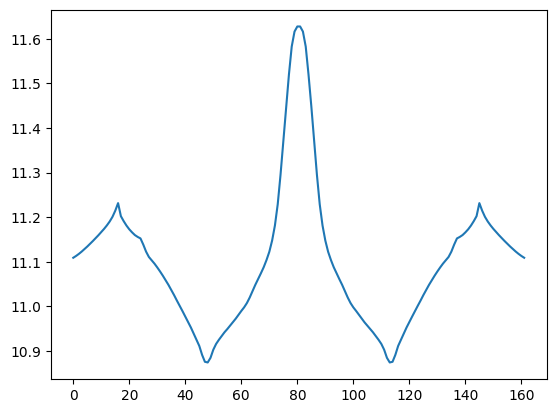

In [15]:
plt.plot(np.log(p_at_face[15:-15]))

/tmp/ipykernel_3514539/2095439099.py:1: RuntimeWarning: invalid value encountered in log
  plt.plot(np.log(ny))


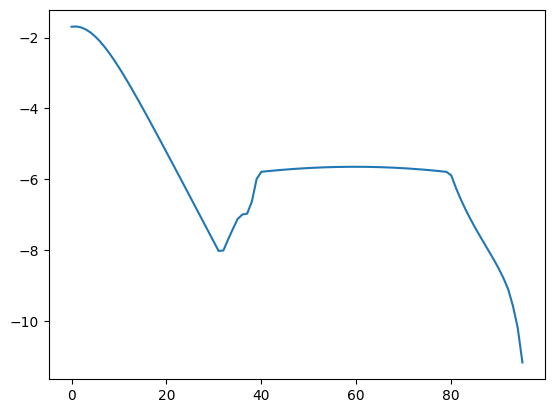

In [16]:
plt.plot(np.log(ny))

In [17]:
nx

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.82103158e-05, -2.49264140e-05, -3.36216035e-05, -4.42275705e-05,
       -5.03697520e-05, -5.18391898e-05, -7.09362357e-05, -1.32023735e-04,
       -1.84448552e-04, -2.03666219e-04, -2.07177538e-04, -2.03800621e-04,
       -2.04602256e-04, -2.07796576e-04, -2.10564234e-04, -2.12445389e-04,
       -2.13168561e-04, -2.12355517e-04, -2.10596481e-04, -2.06760364e-04,
       -2.01561488e-04, -

Drag Coefficient:  0.01106595689793473
Lift Coefficient:  -4.1920774004888806e-09
Pressure Coefficient 2.0915999874073514


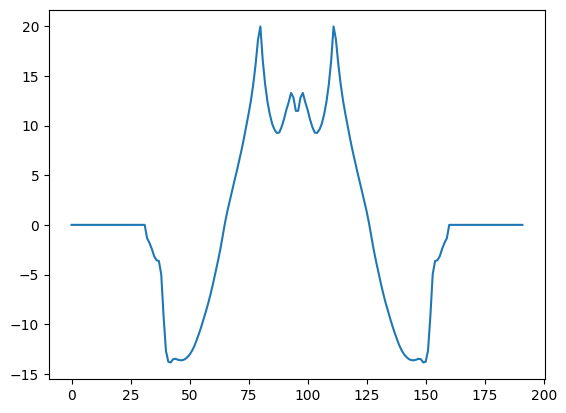

In [22]:
plt.plot(nx*p[0,:])
Den = (.5*rho_inf*V_inf**2)*chord
print("Drag Coefficient: ",np.sum(nx*p_at_face)/Den)
print("Lift Coefficient: ",np.sum((ny*p_at_face)[8*2:-8*2]/Den))
print("Pressure Coefficient",(np.sum((p_at_face-p_inf)[8*2:-8*2]*chord/Den)))

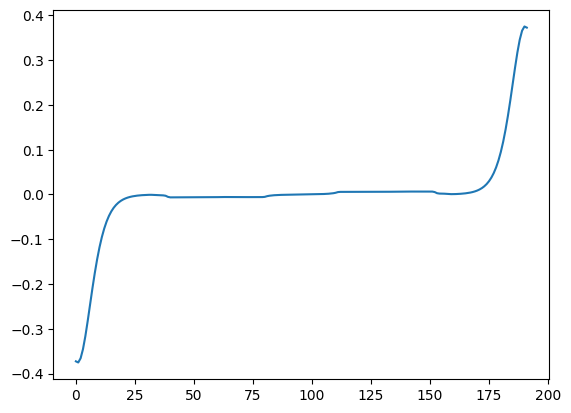

In [19]:

plt.plot(-ny*p_at_face*chord/Den)

In [20]:
write_vtk("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.medium.193x53.grd",rho,u,v,p,output_name="../VTK/Airfoil_Medium.vtk")